Read file and display dataset contents

In [ ]:
import pandas as pd
df=pd.read_csv('/content/house_prices_new_data.csv')
df

,BHK,Type,Area,Status,Price,price_unit
0,2,Apartment,605,Under Construction,3780000.0,L
1,1,Apartment,557,Under Construction,2378250.0,L
2,2,Apartment,635,Under Construction,3780000.0,L
3,1,Apartment,500,Under Construction,2250000.0,L
4,3,Apartment,1259,Ready to move,6536000.0,L
...,...,...,...,...,...,...
6376,2,Apartment,750,Under Construction,3375000.0,L
6377,2,Apartment,980,Ready to Move,4900000.0,L
6378,2,Apartment,1020,Under Construction,4590000.0,L
6379,3,Apartment,1120,Ready to Move,5600000.0,L


Checking attributes

In [ ]:
import pandas as pd
df=pd.read_csv('/content/house_prices_new_data.csv')
#df=df.iloc[:,1:3]
df.head()

,BHK,Type,Area,Status,Price,price_unit
0,2,Apartment,605,Under Construction,3780000.0,L
1,1,Apartment,557,Under Construction,2378250.0,L
2,2,Apartment,635,Under Construction,3780000.0,L
3,1,Apartment,500,Under Construction,2250000.0,L
4,3,Apartment,1259,Ready to move,6536000.0,L


Checking detailed type and attribute(Column) names and no. of data

In [ ]:
import pandas as pd
df=pd.read_csv('/content/house_prices_new_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6381 entries, 0 to 6380
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BHK         6381 non-null   int64  
 1   Type        6381 non-null   object 
 2   Area        6381 non-null   int64  
 3   Status      6381 non-null   object 
 4   Price       6381 non-null   float64
 5   price_unit  6381 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 299.2+ KB


remove leading and trailing spaces of column

In [ ]:
df['price_unit'] = df['price_unit'].str.strip()

Convert price into to Lakhs

In [ ]:
def convert_to_lakh(row):
    if row['price_unit'].lower() in ['cr']:
        return row['price'] * 100   # 1 Cr = 100 Lakh
    else:
        return row['Price']         # already in Lakh

df['price_lakh'] = df.apply(convert_to_lakh, axis=1)

print(df)


      BHK       Type  Area              Status      Price price_unit  \
0       2  Apartment   605  Under Construction  3780000.0          L   
1       1  Apartment   557  Under Construction  2378250.0          L   
2       2  Apartment   635  Under Construction  3780000.0          L   
3       1  Apartment   500  Under Construction  2250000.0          L   
4       3  Apartment  1259       Ready to move  6536000.0          L   
...   ...        ...   ...                 ...        ...        ...   
6376    2  Apartment   750  Under Construction  3375000.0          L   
6377    2  Apartment   980       Ready to Move  4900000.0          L   
6378    2  Apartment  1020  Under Construction  4590000.0          L   
6379    3  Apartment  1120       Ready to Move  5600000.0          L   
6380    3  Apartment  1420  Under Construction  6390000.0          L   

      price_lakh  
0      3780000.0  
1      2378250.0  
2      3780000.0  
3      2250000.0  
4      6536000.0  
...          ...  
63

Required column added and extra data removed

In [ ]:
df['Price'] = df['price_lakh']
df['price_unit'] = 'Lakh'
X = df.drop(columns=['price_lakh'])
y = df['price_lakh']


In [ ]:
df

,BHK,Type,Area,Status,Price,price_unit,price_lakh,price
0,2,Apartment,605,Under Construction,3780000.0,Lakh,3780000.0,3780000.0
1,1,Apartment,557,Under Construction,2378250.0,Lakh,2378250.0,2378250.0
2,2,Apartment,635,Under Construction,3780000.0,Lakh,3780000.0,3780000.0
3,1,Apartment,500,Under Construction,2250000.0,Lakh,2250000.0,2250000.0
4,3,Apartment,1259,Ready to move,6536000.0,Lakh,6536000.0,6536000.0
...,...,...,...,...,...,...,...,...
6376,2,Apartment,750,Under Construction,3375000.0,Lakh,3375000.0,3375000.0
6377,2,Apartment,980,Ready to Move,4900000.0,Lakh,4900000.0,4900000.0
6378,2,Apartment,1020,Under Construction,4590000.0,Lakh,4590000.0,4590000.0
6379,3,Apartment,1120,Ready to Move,5600000.0,Lakh,5600000.0,5600000.0


pick related data

In [ ]:
#df.drop(columns=['locality','region','age'], inplace=True)
df['Status'] = df['Status'].str.capitalize()
df['Type'] = df['Type'].str.capitalize()
df.head()

,BHK,Type,Area,Status,Price,price_unit,price_lakh,price
0,2,Apartment,605,Under construction,3780000.0,Lakh,3780000.0,3780000.0
1,1,Apartment,557,Under construction,2378250.0,Lakh,2378250.0,2378250.0
2,2,Apartment,635,Under construction,3780000.0,Lakh,3780000.0,3780000.0
3,1,Apartment,500,Under construction,2250000.0,Lakh,2250000.0,2250000.0
4,3,Apartment,1259,Ready to move,6536000.0,Lakh,6536000.0,6536000.0


Display relation between variables using Scatter

In [ ]:
#df['age'] = df['age'].str.strip()

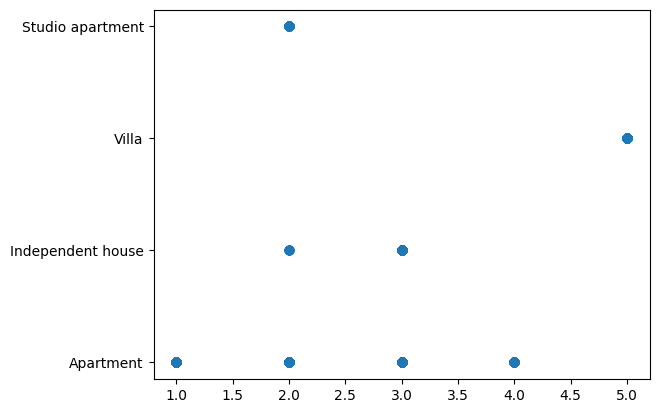

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['BHK'],df['Type'])

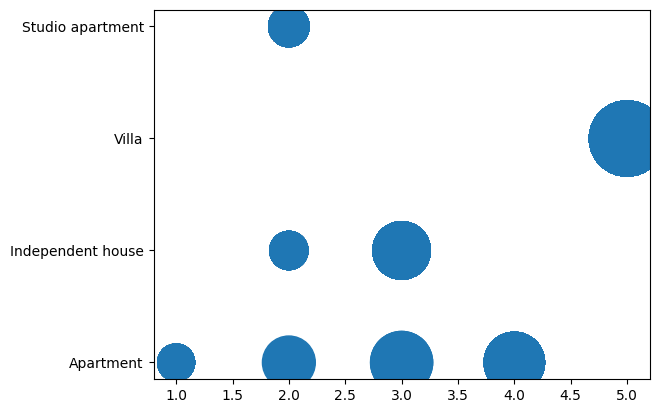

In [ ]:
plt.scatter(df['BHK'],df['Type'],df['Area'])

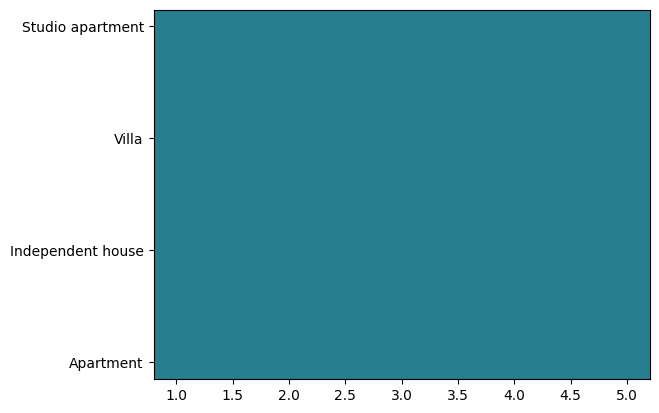

In [ ]:
plt.scatter(df['BHK'],df['Type'],df['Price'],df['Area'])

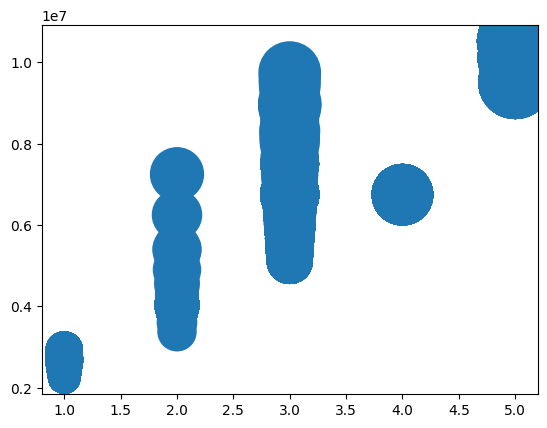

In [ ]:
plt.scatter(df['BHK'],df['Price'],df['Area'])

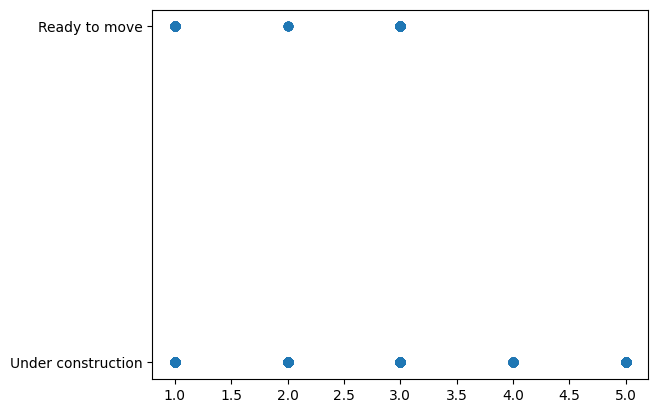

In [ ]:

plt.scatter(df['BHK'],df['Status'])

In [ ]:
df['Status'] = df['Status'].str.strip()
df['Type'] = df['Type'].str.strip()

Machine Learning Model

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Identify column types

In [ ]:
numeric_features = ['BHK', 'Area']
categorical_features = ['Type', 'Status']


Preprocessing (Encoding categorical data)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)


# ***Build ML Pipeline - Linear Regression***

In [ ]:
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])


Train Test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)


Train the model

In [ ]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type', 'Status']),
                                                 ('num', 'passthrough',
                                                  ['BHK', 'Area'])])),
                ('regressor', LinearRegression())])

In [ ]:
import numpy as np
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape)

MAE : 153651.55210016054
RMSE: 238983.04870199604
R2 Score: 0.9885145131848697
MAPE: 3.4655874979222254


Evaluate the model

In [ ]:
y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE : 153651.55210016054
RMSE: 238983.04870199604
R2 Score: 0.9885145131848697


Predict price for a new house

In [ ]:
def main():
  print("House Price Prediction App")

  BHK = int(input("Enter BHK: "))
  Area = float(input("Enter area (sqft): "))
  House_Type = input("Enter type (Apartment/ Villa/ Penthouse/ Independent House): ")
  Status = input("Enter status (Ready to move/Under construction): ")
  if Area < 500:
    print("Invalid input: Area must be at least 500 sq.ft. Please enter again.")

# Condition 2: If area < 700 → only 1 BHK allowed
  elif BHK > 4:
         print("Invalid input: Enter max 3 bhk")

  elif Area < 700 and BHK != 1:
    print("Invalid input: For area less than 700 sq.ft., only 1 BHK is allowed.")


  elif Area >3000:
    print("Invalid area")
 # elif bhk <=0 and house_type == 'Apartment':
#    print("Invalid input: For Type- for 0 bhk dont choose apartment")

 # elif bhk >0 and house_type != 'Apartment':
  #  print("Invalid input: For type - for bhk only choose apartment")

  elif House_Type != 'Apartment' and House_Type != 'Villa' and House_Type != 'Penthouse' and House_Type != 'Independent House':
    print("Invalid input: For type - Enter Apartment or Villa or Penthouse or Independent House")

  elif Status !='Ready to move' and Status !='Under construction':
    print("Invalid input: For statusd - Enter Ready to move or Under construction")



  else:




    import pandas as pd

    new_house = pd.DataFrame({
      'BHK': [BHK],
      'Area': [Area],
      'Type': [House_Type],
      'Status': [Status]
    })

    price = model.predict(new_house)
    print("Predicted Price (in Lakh):", round(price[0], 2))

if __name__ == "__main__":
  main()


House Price Prediction App
Enter BHK: 2
Enter area (sqft): 979
Enter type (Apartment/ Villa/ Penthouse/ Independent House): Apartment
Enter status (Ready to move/Under construction): Under construction
Predicted Price (in Lakh): 4954223.95


In [ ]:
new_house = pd.DataFrame({
    'BHK': [1],
    'Area': [500],
    'Type': ['Apartment'],
    'Status': ['Under construction']
})

predicted_price = model.predict(new_house)
print("Predicted Price (in Lakh):", round(predicted_price[0],2))



Predicted Price (in Lakh): 2991120.29


In [ ]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
pip install gradio

In [ ]:
import gradio as gr
import numpy as np
import pickle

model = pickle.load(open('/content/model.pkl', 'rb'))

def predict(bhk, area, type_house, status):
    type_dict = {"Apartment":0, "Villa":1, "Penthouse":2, "Independent House":3}
    status_dict = {"Ready to move":0, "Under construction":1}

    data = np.array([[bhk, area, type_dict[type_house], status_dict[status]]])
    return model.predict(data)[0]

interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="BHK"),
        gr.Number(label="Area (sqft)"),
        gr.Dropdown(["Apartment", "Villa", "Penthouse", "Independent House"]),
        gr.Radio(["Ready to move", "Under construction"])
    ],
    outputs="text"
)

interface.launch()



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0b691a61194c622b71.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import pickle

with open("/content/model.pkl", "rb") as f:
    model = pickle.load(f)

# Test prediction
prediction = model.predict([[2, 979, 0, 1]])
print(prediction)

ValueError: X has 4 features, but ColumnTransformer is expecting 7 features as input.

In [ ]:
import gradio as gr
import numpy as np
import pickle

model = pickle.load(open('model.pkl', 'rb'))

def predict(BHK, Area, House_Type, Status):
    type_dict = {"Apartment":0, "Villa":1, "Penthouse":2, "Independent House":3}
    status_dict = {"Ready to move":0, "Under construction":1}

    data = np.array([[BHK, Area, type_dict[House_Type], status_dict[Status]]])
    prediction = model.predict(data)
    #return model.predict(data)[0]
    return f"Estimated Price: ₹ {prediction[0]:,.2f}"

interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="BHK"),
        gr.Number(label="Area"),
        gr.Dropdown(["Apartment", "Villa", "Penthouse", "Independent House"]),
        gr.Radio(["Ready to move", "Under construction"])
    ],
    outputs="text"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://24629570d00681523a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
